<a href="https://colab.research.google.com/github/Frankieche24/AVCAD-/blob/main/Avcad_Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sts
from scipy.stats import studentized_range
from itertools import combinations

**Load & clean**

In [3]:
df = pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';')
df.drop(df.iloc[:, 5:15], axis=1, inplace=True)
df.rename(columns={'Sum of Run1_number_all': 'Total_fish_individuals'}, inplace=True)
df.columns = list(map(str, df.columns))
df2 = df.dropna()

sns.set_theme(style='whitegrid', font_scale=1.0)

def clean_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

PART 1 — Mean temp_ann: presence vs. absence of Brown Trout
Standardized vs. non-standardized comparison




PART 1 — temp_ann: presence vs absence of Salmo trutta fario

Shapiro-Wilk (present): W=0.9575, p=5.90e-24
Shapiro-Wilk (absent):  W=0.9375, p=1.45e-17
→ Both groups deviate from normality, so results should be confirmed with both tests.

Levene's test (equal variances): stat=6.230, p=0.0126
→ Use Welch's t-test (does not assume equal variances).

--- H0 (Welch's t-test): mean temp_ann is equal between presence and absence sites ---
Non-standardized: t = -37.5841, p = 3.8956e-215
Standardized:     t = -37.5841, p = 3.8956e-215

--- H0 (Mann-Whitney U): the distribution of temp_ann is the same between groups ---
Non-standardized: U = 220335.5, p = 1.1460e-194
Standardized:     U = 220335.5, p = 1.1460e-194

NOTE: Standardization (z-scoring) is a linear transformation; it does not change
t-test or Mann-Whitney results (statistic magnitudes/p-values are identical),
because both tests are invariant to shifts and positive rescaling of the variable.
Conclusion: p << 0.05 in all four tests → 

/tmp/ipykernel_817/1278173955.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['temp_ann_z'] = (df2['temp_ann'] - df2['temp_ann'].mean()) / df2['temp_ann'].std()


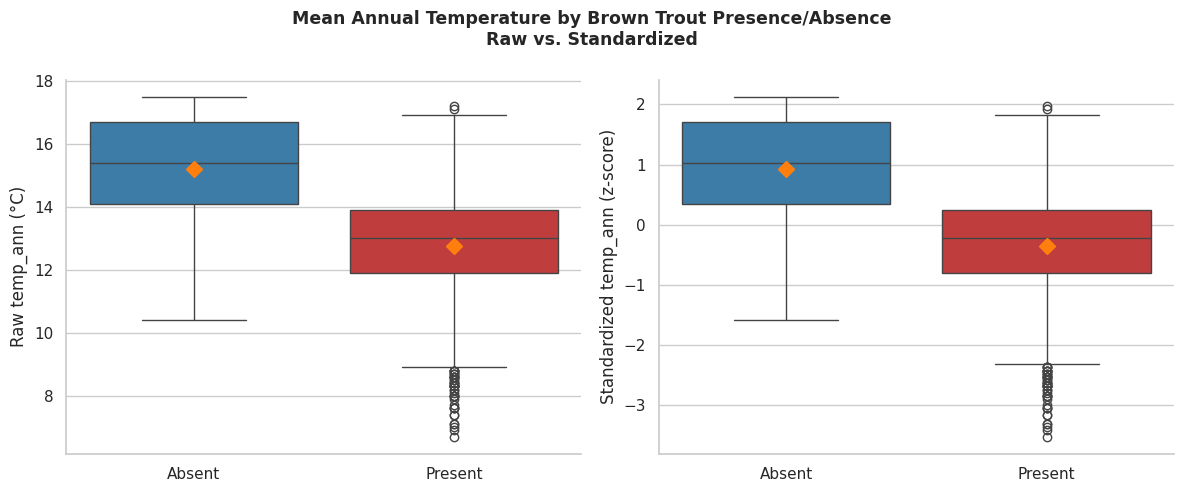

In [4]:
print("="*70)
print("PART 1 — temp_ann: presence vs absence of Salmo trutta fario")
print("="*70)

present = df2[df2['Salmo trutta fario'] == 1]['temp_ann']
absent  = df2[df2['Salmo trutta fario'] == 0]['temp_ann']

# Standardize (z-scores), based on the full sample's mean/SD
df2['temp_ann_z'] = (df2['temp_ann'] - df2['temp_ann'].mean()) / df2['temp_ann'].std()
present_z = df2[df2['Salmo trutta fario'] == 1]['temp_ann_z']
absent_z  = df2[df2['Salmo trutta fario'] == 0]['temp_ann_z']

# Check normality (informs which test is more appropriate)
shap_present = sts.shapiro(present.sample(min(len(present), 5000), random_state=1))
shap_absent  = sts.shapiro(absent.sample(min(len(absent), 5000), random_state=1))
print(f"\nShapiro-Wilk (present): W={shap_present.statistic:.4f}, p={shap_present.pvalue:.2e}")
print(f"Shapiro-Wilk (absent):  W={shap_absent.statistic:.4f}, p={shap_absent.pvalue:.2e}")
print("→ Both groups deviate from normality, so results should be confirmed with both tests.")

# Equal-variance check (Levene's test) -> informs Welch vs Student's t-test choice
lev_stat, lev_p = sts.levene(present, absent)
print(f"\nLevene's test (equal variances): stat={lev_stat:.3f}, p={lev_p:.4f}")
print("→ Use Welch's t-test (does not assume equal variances).")

# --- Welch's t-test (parametric, compares means) ---
t_raw, tp_raw = sts.ttest_ind(present, absent, equal_var=False)
t_z, tp_z = sts.ttest_ind(present_z, absent_z, equal_var=False)

# --- Mann-Whitney U test (non-parametric, compares medians/distributions) ---
u_raw, up_raw = sts.mannwhitneyu(present, absent)
u_z, up_z = sts.mannwhitneyu(present_z, absent_z)

print("\n--- H0 (Welch's t-test): mean temp_ann is equal between presence and absence sites ---")
print(f"Non-standardized: t = {t_raw:.4f}, p = {tp_raw:.4e}")
print(f"Standardized:     t = {t_z:.4f}, p = {tp_z:.4e}")

print("\n--- H0 (Mann-Whitney U): the distribution of temp_ann is the same between groups ---")
print(f"Non-standardized: U = {u_raw:.1f}, p = {up_raw:.4e}")
print(f"Standardized:     U = {u_z:.1f}, p = {up_z:.4e}")

print("\nNOTE: Standardization (z-scoring) is a linear transformation; it does not change")
print("t-test or Mann-Whitney results (statistic magnitudes/p-values are identical),")
print("because both tests are invariant to shifts and positive rescaling of the variable.")
print(f"Conclusion: p << 0.05 in all four tests → REJECT H0. temp_ann differs significantly")
print(f"between presence (mean={present.mean():.2f}°C) and absence (mean={absent.mean():.2f}°C) sites.")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Mean Annual Temperature by Brown Trout Presence/Absence\nRaw vs. Standardized',
             fontsize=12.5, fontweight='bold')

plot_df = pd.concat([
    pd.DataFrame({'temp_ann': present, 'temp_ann_z': present_z, 'Presence': 'Present'}),
    pd.DataFrame({'temp_ann': absent,  'temp_ann_z': absent_z,  'Presence': 'Absent'})
])

for ax, col, lbl in zip(axes, ['temp_ann', 'temp_ann_z'],
                          ['Raw temp_ann (°C)', 'Standardized temp_ann (z-score)']):
    sns.boxplot(data=plot_df, x='Presence', y=col, order=['Absent', 'Present'],
                hue='Presence', palette=['#d62728', '#2c7fb8'], legend=False, ax=ax)
    for i, cat in enumerate(['Absent', 'Present']):
        m = plot_df[plot_df['Presence'] == cat][col].mean()
        ax.plot(i, m, 'D', color='#ff7f0e', markersize=8, zorder=5)
    ax.set_ylabel(lbl)
    ax.set_xlabel('')
    clean_ax(ax)

plt.tight_layout()
plt.savefig('part1_temp_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


**PART 2 — Independence of trout presence/absence and Country (Chi-square test)**


PART 2 — Independence of trout presence and Country

Contingency table:
           Absent (0)  Present (1)
Country                          
Italy             26           25
Portugal         614          252
Spain            140         1765

H0: Presence/absence of Salmo trutta fario is independent of Country
Chi-square test: chi2 = 1216.393, df = 2, p = 7.3059e-265
Expected counts (under independence):
           Absent (0)  Present (1)
Country                          
Italy           14.1         36.9
Portugal       239.4        626.6
Spain          526.5       1378.5
→ REJECT H0: presence/absence of Brown Trout is NOT independent of Country.
Cramér's V (effect size): 0.657


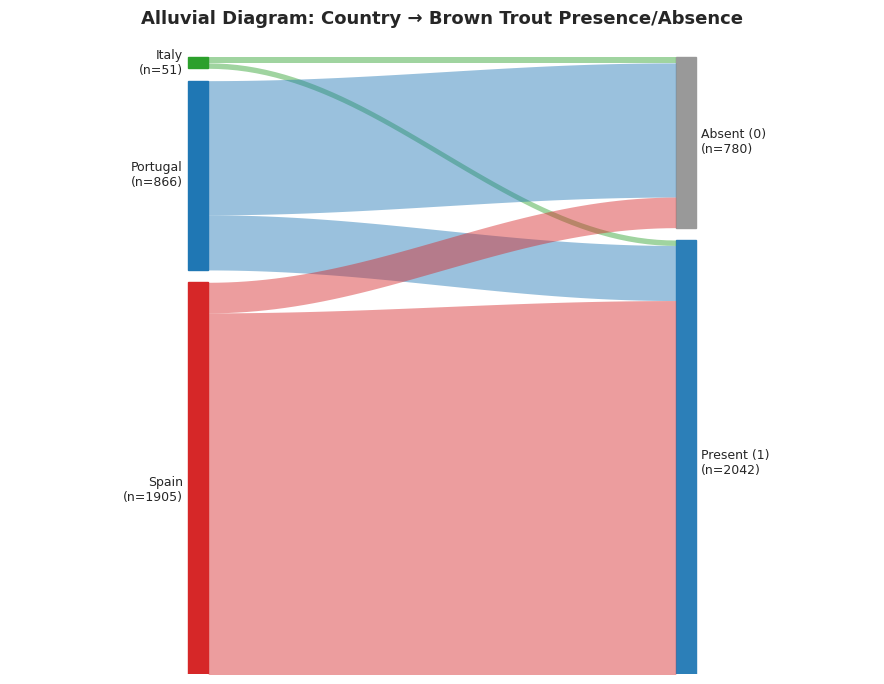

In [5]:
print("\n" + "="*70)
print("PART 2 — Independence of trout presence and Country")
print("="*70)

ct = pd.crosstab(df2['Country'], df2['Salmo trutta fario'])
ct.columns = ['Absent (0)', 'Present (1)']
print("\nContingency table:\n", ct)

chi2, p_chi2, dof, expected = sts.chi2_contingency(ct)
print(f"\nH0: Presence/absence of Salmo trutta fario is independent of Country")
print(f"Chi-square test: chi2 = {chi2:.3f}, df = {dof}, p = {p_chi2:.4e}")
print("Expected counts (under independence):\n", pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

if p_chi2 < 0.05:
    print("→ REJECT H0: presence/absence of Brown Trout is NOT independent of Country.")
else:
    print("→ FAIL TO REJECT H0: no evidence of association.")

# Cramér's V (effect size for chi-square)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Cramér's V (effect size): {cramers_v:.3f}")

# --- Alluvial / Sankey-style diagram (built manually with matplotlib) ---
countries = ct.index.tolist()
presence_labels = ['Absent (0)', 'Present (1)']
country_colors = {'Italy': '#2ca02c', 'Portugal': '#1f77b4', 'Spain': '#d62728'}

fig, ax = plt.subplots(figsize=(9, 7))
left_x, right_x, node_width, gap = 0, 1, 0.04, 0.02

country_totals = ct.sum(axis=1)
presence_totals = ct.sum(axis=0)
total = country_totals.sum()

# Node y-positions (stacked vertically, proportional to totals)
left_positions, y_cursor = {}, 1
for c in countries:
    h = country_totals[c] / total
    left_positions[c] = (y_cursor - h, y_cursor)
    y_cursor -= h + gap

right_positions, y_cursor = {}, 1
for p in presence_labels:
    h = presence_totals[p] / total
    right_positions[p] = (y_cursor - h, y_cursor)
    y_cursor -= h + gap

for c in countries:
    y0, y1 = left_positions[c]
    ax.add_patch(plt.Rectangle((left_x, y0), node_width, y1 - y0, color=country_colors[c]))
    ax.text(left_x - 0.01, (y0 + y1) / 2, f"{c}\n(n={country_totals[c]})", ha='right', va='center', fontsize=9)

presence_colors = {'Absent (0)': '#999999', 'Present (1)': '#2c7fb8'}
for p in presence_labels:
    y0, y1 = right_positions[p]
    ax.add_patch(plt.Rectangle((right_x - node_width, y0), node_width, y1 - y0, color=presence_colors[p]))
    ax.text(right_x + 0.01, (y0 + y1) / 2, f"{p}\n(n={presence_totals[p]})", ha='left', va='center', fontsize=9)

def bezier_ribbon(ax, x0, y0_top, y0_bot, x1, y1_top, y1_bot, color, alpha=0.45):
    n_pts = 50
    xs = np.linspace(x0, x1, n_pts)
    ease = (1 - np.cos(np.pi * (xs - x0) / (x1 - x0))) / 2
    top = y0_top + (y1_top - y0_top) * ease
    bot = y0_bot + (y1_bot - y0_bot) * ease
    ax.fill_between(xs, bot, top, color=color, alpha=alpha, linewidth=0)

left_cursor = {c: left_positions[c][1] for c in countries}
right_cursor = {p: right_positions[p][1] for p in presence_labels}

for c in countries:
    for p in presence_labels:
        val = ct.loc[c, p]
        h = val / total
        if h <= 0:
            continue
        y0_top = left_cursor[c]; y0_bot = y0_top - h; left_cursor[c] = y0_bot
        y1_top = right_cursor[p]; y1_bot = y1_top - h; right_cursor[p] = y1_bot
        bezier_ribbon(ax, left_x + node_width, y0_top, y0_bot,
                      right_x - node_width, y1_top, y1_bot, color=country_colors[c])

ax.set_xlim(-0.35, 1.35)
ax.set_ylim(0, 1.02)
ax.axis('off')
ax.set_title('Alluvial Diagram: Country → Brown Trout Presence/Absence',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('part2_alluvial.png', dpi=150, bbox_inches='tight')
plt.show()

**PART 3 — ANOVA: mean Elevation_mean_catch across the 8 most-sampled catchments**


PART 3 — ANOVA: Elevation_mean_catch across top-8 catchments

Catchments analyzed: ['Galiza-Norte', 'Minho', 'Cantabrica', 'Douro', 'Tejo', 'Guadia', 'Galiza-Sul', 'Mondego']
Sample sizes: [702, 699, 345, 272, 235, 102, 95, 86]

H0: The mean Elevation_mean_catch is equal across all 8 catchments
One-way ANOVA: F = 157.174, p = 3.9710e-193
→ REJECT H0: at least one catchment differs in mean elevation.

Tukey HSD post-hoc test (q_critical = 4.290 at α=0.05):
      Group1     Group2  Mean Diff  q-stat     p-adj Significant
Galiza-Norte      Minho     -477.1   40.97         0         Yes
Galiza-Norte Cantabrica     -219.1   15.29         0         Yes
Galiza-Norte      Douro     -332.5   21.36         0         Yes
       Minho Cantabrica        258      18         0         Yes
       Minho    Mondego      298.4   11.98         0         Yes
  Cantabrica       Tejo      202.2   10.97         0         Yes
       Minho     Guadia      588.6   25.49         0         Yes
       Minho       

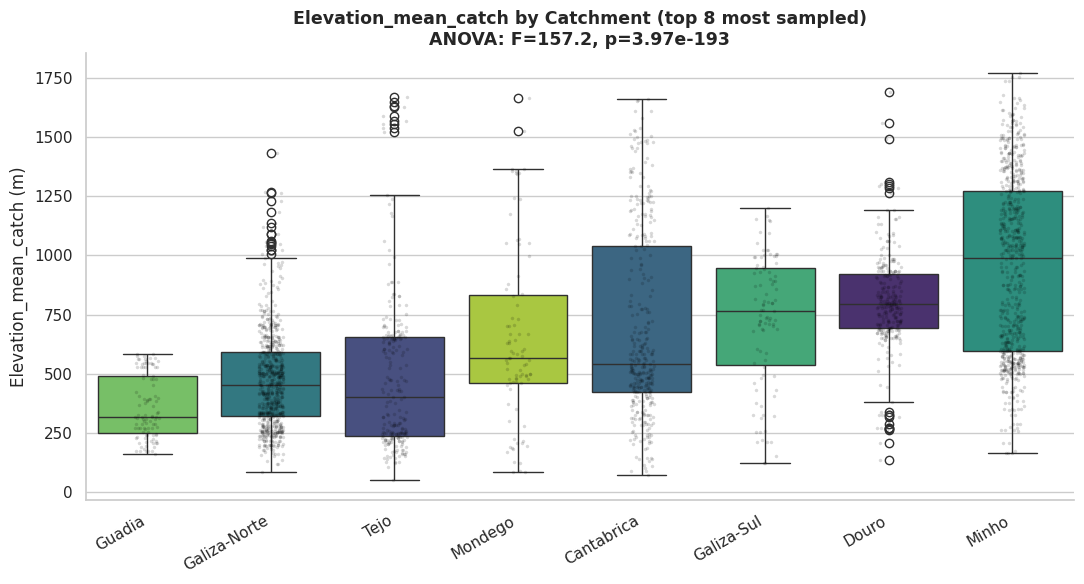

In [6]:
print("\n" + "="*70)
print("PART 3 — ANOVA: Elevation_mean_catch across top-8 catchments")
print("="*70)

top8 = df2['Catchment_name'].value_counts().head(8).index.tolist()
sub = df2[df2['Catchment_name'].isin(top8)]
groups = [sub[sub['Catchment_name'] == c]['Elevation_mean_catch'].values for c in top8]

print(f"\nCatchments analyzed: {top8}")
print(f"Sample sizes: {[len(g) for g in groups]}")

f_stat, p_anova = sts.f_oneway(*groups)
print(f"\nH0: The mean Elevation_mean_catch is equal across all 8 catchments")
print(f"One-way ANOVA: F = {f_stat:.3f}, p = {p_anova:.4e}")
if p_anova < 0.05:
    print("→ REJECT H0: at least one catchment differs in mean elevation.")

# --- Manual Tukey HSD post-hoc test (no statsmodels dependency) ---
all_vals = np.concatenate(groups)
grand_n = len(all_vals)
k = len(groups)
group_means = [g.mean() for g in groups]
group_ns = [len(g) for g in groups]
ss_within = sum(((g - g.mean()) ** 2).sum() for g in groups)
df_within = grand_n - k
mse = ss_within / df_within
alpha = 0.05
q_crit = studentized_range.ppf(1 - alpha, k, df_within)

tukey_results = []
for i, j in combinations(range(k), 2):
    n_i, n_j = group_ns[i], group_ns[j]
    se = np.sqrt(mse / 2 * (1 / n_i + 1 / n_j))
    mean_diff = group_means[i] - group_means[j]
    q_stat = abs(mean_diff) / se
    p_adj = studentized_range.sf(q_stat, k, df_within)
    tukey_results.append({
        'Group1': top8[i], 'Group2': top8[j],
        'Mean Diff': round(mean_diff, 1), 'q-stat': round(q_stat, 3),
        'p-adj': p_adj, 'Significant': 'Yes' if p_adj < alpha else 'No'
    })

tukey_df = pd.DataFrame(tukey_results).sort_values('p-adj')
print(f"\nTukey HSD post-hoc test (q_critical = {q_crit:.3f} at α=0.05):")
pd.set_option('display.float_format', lambda x: f'{x:.4g}')
print(tukey_df.to_string(index=False))

n_sig_tukey = (tukey_df['Significant'] == 'Yes').sum()
print(f"\n{n_sig_tukey} out of {len(tukey_df)} pairwise comparisons are significant (Tukey HSD).")

# --- Visualization ---
fig, ax = plt.subplots(figsize=(11, 6))
order = sub.groupby('Catchment_name')['Elevation_mean_catch'].mean().sort_values().index
sns.boxplot(data=sub, x='Catchment_name', y='Elevation_mean_catch', order=order,
            hue='Catchment_name', palette='viridis', legend=False, ax=ax)
sns.stripplot(data=sub, x='Catchment_name', y='Elevation_mean_catch', order=order,
              color='black', alpha=0.15, size=2.5, ax=ax)
ax.set_title(f'Elevation_mean_catch by Catchment (top 8 most sampled)\nANOVA: F={f_stat:.1f}, p={p_anova:.2e}',
             fontsize=12.5, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Elevation_mean_catch (m)')
plt.xticks(rotation=30, ha='right')
clean_ax(ax)
plt.tight_layout()
plt.savefig('part3_elevation_anova.png', dpi=150, bbox_inches='tight')
plt.show()


**PART 4 — Non-parametric equivalent: Kruskal-Wallis + Dunn's post-hoc test**


PART 4 — Kruskal-Wallis (non-parametric equivalent of ANOVA)

H0: The distributions (medians) of Elevation_mean_catch are equal across all 8 catchments
Kruskal-Wallis test: H = 832.765, p = 1.5742e-175
→ REJECT H0: at least one catchment differs in elevation distribution.

Dunn's post-hoc test (Bonferroni-corrected, α=0.05):
      Group1     Group2  z-stat  p-adj (Bonferroni) Significant
Galiza-Norte      Minho  -23.64                   0         Yes
Galiza-Norte Cantabrica  -8.377                   0         Yes
Galiza-Norte      Douro  -15.96                   0         Yes
       Minho Cantabrica   10.83                   0         Yes
       Minho     Guadia   15.71                   0         Yes
  Cantabrica     Guadia   8.448                   0         Yes
       Minho       Tejo   16.79                   0         Yes
       Douro     Guadia   13.28                   0         Yes
       Douro       Tejo   12.83                   0         Yes
      Guadia Galiza-Sul  -8.647 

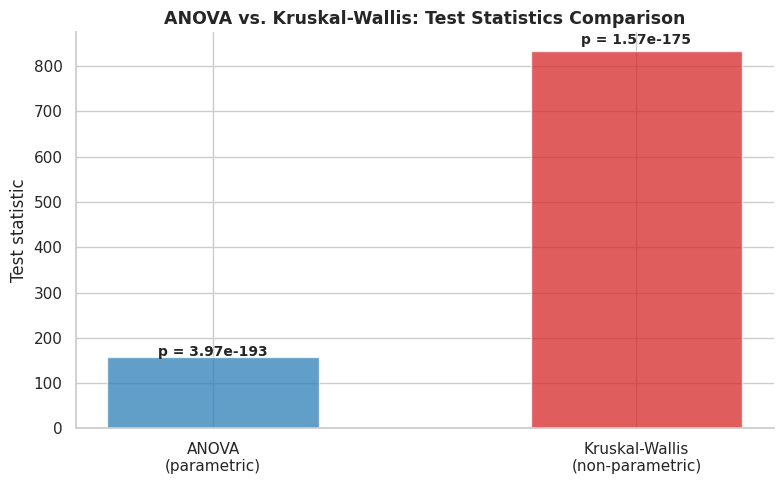

In [7]:
print("\n" + "="*70)
print("PART 4 — Kruskal-Wallis (non-parametric equivalent of ANOVA)")
print("="*70)

h_stat, p_kw = sts.kruskal(*groups)
print(f"\nH0: The distributions (medians) of Elevation_mean_catch are equal across all 8 catchments")
print(f"Kruskal-Wallis test: H = {h_stat:.3f}, p = {p_kw:.4e}")
if p_kw < 0.05:
    print("→ REJECT H0: at least one catchment differs in elevation distribution.")

# --- Manual Dunn's post-hoc test with Bonferroni correction ---
ranks = sts.rankdata(all_vals)
idx = 0
rank_groups = []
for g in groups:
    rank_groups.append(ranks[idx: idx + len(g)])
    idx += len(g)

mean_ranks = [r.mean() for r in rank_groups]
_, counts = np.unique(all_vals, return_counts=True)
tie_correction = 1 - (counts ** 3 - counts).sum() / (grand_n ** 3 - grand_n)
n_pairs = k * (k - 1) // 2

dunn_results = []
for i, j in combinations(range(k), 2):
    se = np.sqrt(tie_correction * (grand_n * (grand_n + 1) / 12) * (1 / group_ns[i] + 1 / group_ns[j]))
    z_stat = (mean_ranks[i] - mean_ranks[j]) / se
    p_raw = 2 * (1 - sts.norm.cdf(abs(z_stat)))
    p_adj = min(p_raw * n_pairs, 1.0)  # Bonferroni correction
    dunn_results.append({
        'Group1': top8[i], 'Group2': top8[j],
        'z-stat': round(z_stat, 3), 'p-adj (Bonferroni)': p_adj,
        'Significant': 'Yes' if p_adj < alpha else 'No'
    })

dunn_df = pd.DataFrame(dunn_results).sort_values('p-adj (Bonferroni)')
print(f"\nDunn's post-hoc test (Bonferroni-corrected, α=0.05):")
print(dunn_df.to_string(index=False))

n_sig_dunn = (dunn_df['Significant'] == 'Yes').sum()
print(f"\n{n_sig_dunn} out of {len(dunn_df)} pairwise comparisons are significant (Dunn's test).")

# --- Comparison: ANOVA vs. Kruskal-Wallis ---
print("\n" + "-"*70)
print("COMPARISON: ANOVA vs. Kruskal-Wallis")
print("-"*70)
print(f"ANOVA:          F = {f_stat:.3f}, p = {p_anova:.4e}")
print(f"Kruskal-Wallis: H = {h_stat:.3f}, p = {p_kw:.4e}")
print(f"Significant pairs — Tukey HSD: {n_sig_tukey}/{len(tukey_df)} | Dunn's test: {n_sig_dunn}/{len(dunn_df)}")
print("\nBoth tests agree on the overall conclusion (highly significant differences among catchments),")
print("and largely agree on which pairs differ. Minor discrepancies in borderline pairs are expected,")
print("since ANOVA/Tukey compare means (sensitive to outliers and assumes normality), while")
print("Kruskal-Wallis/Dunn's compare rank-based distributions (robust to outliers and skew).")
print("Given Elevation_mean_catch is approximately normal here, parametric ANOVA results should be reliable,")
print("and the non-parametric test serves as a robustness check.")

# --- Side-by-side visualization ---
fig, ax = plt.subplots(figsize=(8, 5))
tests = ['ANOVA\n(parametric)', 'Kruskal-Wallis\n(non-parametric)']
stats_vals = [f_stat, h_stat]
p_vals = [p_anova, p_kw]
bars = ax.bar(tests, stats_vals, color=['#2c7fb8', '#d62728'], alpha=0.75, width=0.5)
for bar, p in zip(bars, p_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
            f'p = {p:.2e}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test statistic')
ax.set_title('ANOVA vs. Kruskal-Wallis: Test Statistics Comparison', fontsize=12.5, fontweight='bold')
clean_ax(ax)
plt.tight_layout()
plt.savefig('part4_anova_vs_kruskal.png', dpi=150, bbox_inches='tight')
plt.show()

Placed EFIplus_medit.zip in my working directory — pd.read_csv('EFIplus_medit.zip', compression='zip', sep=';') reads it directly, no manual unzipping needed

Part 1: Confirms that standardization (z-scoring) doesn't change t-test/Mann-Whitney results — a useful didactic point about scale-invariance of these tests

Part 2: Chi-square test + a manually-built alluvial/Sankey diagram using matplotlib (no plotly/holoviews dependency, since those aren't available in this environment)

Part 3: One-way ANOVA + a from-scratch Tukey HSD implementation using scipy.stats.studentized_range (avoids needing statsmodels, which isn't installed here)

Part 4: Kruskal-Wallis + a from-scratch Dunn's post-hoc test with Bonferroni correction, plus a direct statistical comparison against Part 3's ANOVA results